# DensePolarNet for Strong Lens Finding (Kaggle Notebook)

This notebook implements a **physics-informed, lightweight lens finder** for the dataset with:
- `train_lenses`
- `train_nonlenses`
- `test_lenses`
- `test_nonlenses`

## Core idea

Use a **small-image DenseNet backbone** on the original `(3, 64, 64)` cutout **plus** a **polar-coordinate branch**.

Why this helps:
- In Cartesian space, arcs/rings are curved and appear in many orientations.
- In **polar space**, a ring-like lens feature becomes a near-horizontal band at roughly constant radius.
- That gives the model an inductive bias toward what strong lensing actually looks like.

The model therefore combines:
1. **DenseNet branch** → local morphology, color consistency, texture
2. **Polar CNN branch** → arc/ring geometry
3. **Radial-profile branch** → flux excess at Einstein-radius-like annuli

This is intentionally built for **Kaggle + P100**:
- small input size
- mixed precision
- balanced sampling for class imbalance
- ROC/AUC evaluation
- D4 test-time augmentation

In [1]:
# # RUN THIS AS THE FIRST CELL IN A FRESH SESSION
# !pip uninstall -y -q torch torchvision torchaudio
# !pip install -q --no-cache-dir --force-reinstall \
#     torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 \
#     --index-url https://download.pytorch.org/whl/cu118

In [2]:
import torch, torchvision

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("arch list:", torch.cuda.get_arch_list())

torch: 2.4.1+cu118
torch cuda: 11.8
cuda available: True
gpu: Tesla P100-PCIE-16GB
arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']


In [3]:
use_cuda = torch.cuda.is_available() and ("sm_60" in torch.cuda.get_arch_list())
device = torch.device("cuda" if use_cuda else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import torch.nn as nn

x = torch.randn(4, 3, 64, 64).to(device)
conv = nn.Conv2d(3, 8, kernel_size=3, padding=1).to(device)

with torch.no_grad():
    y = conv(x)

print("Smoke test output shape:", y.shape)

Smoke test output shape: torch.Size([4, 8, 64, 64])


In [5]:
import os
import gc
import math
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

import torchvision
from torchvision.models import (
    densenet121, densenet161,
    DenseNet121_Weights, DenseNet161_Weights
)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cuda
torch: 2.4.1+cu118
torchvision: 0.19.1+cu118


In [6]:
class CFG:
    # model
    MODEL_NAME = "densenet161"   # selected for final runs on Kaggle P100
    PRETRAINED = False           # set True if Kaggle internet/cache is available
    SMALL_IMAGE_STEM = True      # crucial for 64x64 astronomy cutouts
    USE_POLAR_BRANCH = True
    USE_RADIAL_BRANCH = True

    # data
    IMG_SIZE = 64
    VALID_SIZE = 0.10
    NUM_WORKERS = 2

    # training
    EPOCHS = 20
    BATCH_SIZE = 24
    LR = 2e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5
    AMP = True

    # loss
    FOCAL_ALPHA = 0.75
    FOCAL_GAMMA = 2.0

    # augmentation
    MAX_SHIFT = 4
    P_FLIP = 0.5

    # inference
    USE_TTA = True
    TTA_D4 = True

    # paths
    ROOT = None

print(CFG.__dict__)

{'__module__': '__main__', 'MODEL_NAME': 'densenet161', 'PRETRAINED': False, 'SMALL_IMAGE_STEM': True, 'USE_POLAR_BRANCH': True, 'USE_RADIAL_BRANCH': True, 'IMG_SIZE': 64, 'VALID_SIZE': 0.1, 'NUM_WORKERS': 2, 'EPOCHS': 20, 'BATCH_SIZE': 24, 'LR': 0.0002, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 5, 'AMP': True, 'FOCAL_ALPHA': 0.75, 'FOCAL_GAMMA': 2.0, 'MAX_SHIFT': 4, 'P_FLIP': 0.5, 'USE_TTA': True, 'TTA_D4': True, 'ROOT': None, '__dict__': <attribute '__dict__' of 'CFG' objects>, '__weakref__': <attribute '__weakref__' of 'CFG' objects>, '__doc__': None}


In [7]:
def find_dataset_root():
    needed = ["train_lenses", "train_nonlenses", "test_lenses", "test_nonlenses"]

    explicit_candidates = [
        Path("/kaggle/input/datasets/arushhh/dataset-task-v"),
        Path("/kaggle/input/dataset-task-v"),
    ]
    for root in explicit_candidates:
        if root.exists() and all((root / x).exists() for x in needed):
            return root

    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir() and all((p / x).exists() for x in needed):
            return p

    raise FileNotFoundError("Could not find dataset root in /kaggle/input with the expected folders.")

CFG.ROOT = find_dataset_root()
print("Using dataset root:", CFG.ROOT)

Using dataset root: /kaggle/input/datasets/arushhh/dataset-task-v


In [8]:
def build_dataframe(root):
    rows = []
    mapping = {
        "train_lenses": (1, "train"),
        "train_nonlenses": (0, "train"),
        "test_lenses": (1, "test"),
        "test_nonlenses": (0, "test"),
    }

    for folder, (label, split) in mapping.items():
        folder_path = Path(root) / folder
        files = sorted(folder_path.glob("*.npy"))
        rows.extend([{
            "path": str(f),
            "label": label,
            "split": split,
            "folder": folder
        } for f in files])

    df = pd.DataFrame(rows)
    return df

df = build_dataframe(CFG.ROOT)
display(df.head())
print(df.groupby(["split", "folder", "label"]).size())
print("\nTotal:", len(df))

,path,label,split,folder
0,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
1,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
2,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
3,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses
4,/kaggle/input/datasets/arushhh/dataset-task-v/...,1,train,train_lenses


split  folder           label
test   test_lenses      1          195
       test_nonlenses   0        19455
train  train_lenses     1         1730
       train_nonlenses  0        28675
dtype: int64

Total: 50055


In [9]:
train_df = df[df["split"] == "train"].reset_index(drop=True).copy()
test_df  = df[df["split"] == "test"].reset_index(drop=True).copy()

# Submission requirement: make a 90:10 stratified split inside the provided training set only.
# The provided test folders remain untouched as a final held-out evaluation set.
train_idx, valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=CFG.VALID_SIZE,
    stratify=train_df["label"].values,
    random_state=SEED
)

trn_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[valid_idx].reset_index(drop=True)

print("train size:", len(trn_df), "positive fraction:", trn_df.label.mean())
print("valid size:", len(val_df), "positive fraction:", val_df.label.mean())
print("test  size:", len(test_df), "positive fraction:", test_df.label.mean())

train size: 27364 positive fraction: 0.05689957608536764
valid size: 3041 positive fraction: 0.056889181190397896
test  size: 19650 positive fraction: 0.009923664122137405


In [10]:
def load_npy(path):
    x = np.load(path)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # expected (3, 64, 64), but handle channels-last just in case
    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape} for {path}")

    if x.shape[0] == 3:
        pass
    elif x.shape[-1] == 3:
        x = np.transpose(x, (2, 0, 1))
    else:
        raise ValueError(f"Expected channel dimension of 3, got shape {x.shape} for {path}")

    return x

def astrophysical_stretch(x):
    # x: (C,H,W)
    # lens papers often clip negatives and apply sqrt / Lupton-style stretches.
    # We use a robust asinh stretch: stable for astronomy, gentle on bright cores, keeps faint arcs visible.
    x = np.maximum(x, 0.0)

    out = np.zeros_like(x, dtype=np.float32)
    for c in range(x.shape[0]):
        scale = np.percentile(x[c], 99.5)
        scale = max(scale, 1e-6)
        y = np.arcsinh(x[c] / scale)
        y = y / max(np.arcsinh(1.0), 1e-6)
        out[c] = y.astype(np.float32)

    return out

def random_rot90(x):
    k = np.random.randint(0, 4)
    return np.rot90(x, k, axes=(1, 2)).copy()

def random_flip(x):
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, :, ::-1].copy()
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, ::-1, :].copy()
    return x

def random_shift(x, max_shift=4):
    if max_shift <= 0:
        return x
    dx = np.random.randint(-max_shift, max_shift + 1)
    dy = np.random.randint(-max_shift, max_shift + 1)

    pad = max_shift
    xp = np.pad(x, ((0, 0), (pad, pad), (pad, pad)), mode="reflect")
    h, w = x.shape[1:]
    sx = pad + dx
    sy = pad + dy
    return xp[:, sy:sy+h, sx:sx+w].copy()

class LensDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_npy(row.path)

        if self.augment:
            x = random_rot90(x)
            x = random_flip(x)
            x = random_shift(x, CFG.MAX_SHIFT)

        x = astrophysical_stretch(x)
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row.label, dtype=torch.float32)
        return x, y

torch.Size([3, 64, 64]) torch.float32 tensor(0.)


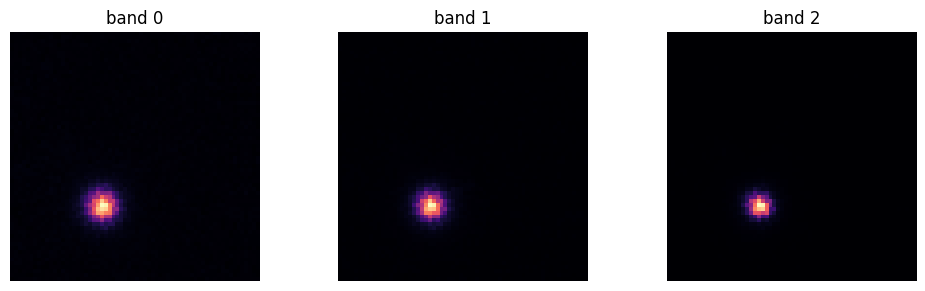

In [11]:
# quick sanity check
sample_x, sample_y = LensDataset(trn_df, augment=True)[0]
print(sample_x.shape, sample_x.dtype, sample_y)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(sample_x[i].numpy(), cmap="magma")
    axes[i].set_title(f"band {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [12]:
train_labels = trn_df["label"].values
class_counts = np.bincount(train_labels.astype(int))
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels.astype(int)]
train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_ds = LensDataset(trn_df, augment=True)
valid_ds = LensDataset(val_df, augment=False)
test_ds  = LensDataset(test_df, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)
valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print("train steps:", len(train_loader))
print("valid steps:", len(valid_loader))
print("test steps :", len(test_loader))

train steps: 1140
valid steps: 127
test steps : 819


In [13]:
def d4_transforms(x):
    # returns list of D4 transforms for TTA
    outs = []
    for k in range(4):
        r = torch.rot90(x, k=k, dims=(-2, -1))
        outs.append(r)
        outs.append(torch.flip(r, dims=(-1,)))
    return outs

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()

class PolarTransform(nn.Module):
    def __init__(self, radial_bins=32, angular_bins=64):
        super().__init__()
        self.radial_bins = radial_bins
        self.angular_bins = angular_bins

        r = torch.linspace(0, 1, radial_bins)
        theta = torch.linspace(0, 2 * math.pi, angular_bins)
        rr, tt = torch.meshgrid(r, theta, indexing="ij")

        # normalized grid in [-1, 1]
        x = rr * torch.cos(tt)
        y = rr * torch.sin(tt)
        grid = torch.stack([x, y], dim=-1)  # [R, T, 2]
        self.register_buffer("base_grid", grid)

    def forward(self, x):
        # x: [B, C, H, W]
        b = x.shape[0]
        grid = self.base_grid.unsqueeze(0).repeat(b, 1, 1, 1)  # [B, R, T, 2]
        # grid_sample expects x coord in last dim index 0, y coord index 1
        polar = F.grid_sample(
            x, grid,
            mode="bilinear",
            padding_mode="zeros",
            align_corners=True
        )
        return polar  # [B, C, R, T]

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class DensePolarNet(nn.Module):
    def __init__(self, model_name="densenet121", pretrained=False, small_image_stem=True,
                 use_polar_branch=True, use_radial_branch=True):
        super().__init__()
        self.use_polar_branch = use_polar_branch
        self.use_radial_branch = use_radial_branch

        # --- Dense backbone ---
        if model_name == "densenet121":
            weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet121(weights=weights)
            except Exception:
                self.backbone = densenet121(weights=None)
        elif model_name == "densenet161":
            weights = DenseNet161_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet161(weights=weights)
            except Exception:
                self.backbone = densenet161(weights=None)
        else:
            raise ValueError("model_name must be 'densenet121' or 'densenet161'")

        dense_dim = self.backbone.classifier.in_features

        if small_image_stem:
            old = self.backbone.features.conv0
            self.backbone.features.conv0 = nn.Conv2d(
                3, old.out_channels, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.features.pool0 = nn.Identity()

        self.backbone.classifier = nn.Identity()

        # --- Polar branch ---
        polar_dim = 0
        radial_dim = 0
        if self.use_polar_branch:
            self.polar = PolarTransform(radial_bins=32, angular_bins=64)
            self.polar_cnn = nn.Sequential(
                ConvBNAct(3, 32, 3, 1, 1),
                nn.MaxPool2d(2),
                ConvBNAct(32, 64, 3, 1, 1),
                nn.MaxPool2d(2),
                ConvBNAct(64, 128, 3, 1, 1),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            polar_dim = 128

        # --- Radial profile branch ---
        if self.use_radial_branch:
            self.radial_head = nn.Sequential(
                nn.Conv1d(3, 32, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool1d(1)
            )
            radial_dim = 64

        fused_dim = dense_dim + polar_dim + radial_dim

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        feats = []

        dense_feat = self.backbone(x)
        feats.append(dense_feat)

        if self.use_polar_branch:
            polar = self.polar(x)               # [B, C, R, T]
            polar_feat = self.polar_cnn(polar).flatten(1)
            feats.append(polar_feat)

            if self.use_radial_branch:
                radial = polar.mean(dim=-1)     # [B, C, R]
                radial_feat = self.radial_head(radial).flatten(1)
                feats.append(radial_feat)

        fused = torch.cat(feats, dim=1)
        logit = self.head(fused).squeeze(1)
        return logit

model = DensePolarNet(
    model_name=CFG.MODEL_NAME,
    pretrained=CFG.PRETRAINED,
    small_image_stem=CFG.SMALL_IMAGE_STEM,
    use_polar_branch=CFG.USE_POLAR_BRANCH,
    use_radial_branch=CFG.USE_RADIAL_BRANCH
).to(device)

dummy = torch.randn(2, 3, 64, 64).to(device)
with torch.no_grad():
    out = model(dummy)
print("output shape:", out.shape)
print("n params:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

output shape: torch.Size([2])
n params: 27.179777 M


In [14]:
criterion = BinaryFocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2, verbose=True
)
scaler = GradScaler(enabled=CFG.AMP)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with autocast(enabled=CFG.AMP):
            logits = model(x)
            loss = criterion(logits, y)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        losses.append(loss.item())
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    auc = roc_auc_score(all_targets, all_probs)
    return float(np.mean(losses)), float(auc), all_targets, all_probs

best_auc = -np.inf
best_state = None
best_epoch = 0
history = []

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    train_loss, train_auc, _, _ = run_epoch(model, train_loader, optimizer)
    valid_loss, valid_auc, _, _ = run_epoch(model, valid_loader, optimizer=None)

    scheduler.step(valid_auc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_auc": train_auc,
        "valid_loss": valid_loss,
        "valid_auc": valid_auc,
        "lr": optimizer.param_groups[0]["lr"]
    })

    if valid_auc > best_auc:
        best_auc = valid_auc
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "/kaggle/working/best_densepolar.pt")

    dt = time.time() - t0
    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_auc={train_auc:.4f} | "
        f"valid_loss={valid_loss:.4f} valid_auc={valid_auc:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | {dt:.1f}s"
    )

    if epoch - best_epoch >= CFG.PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch} with valid AUC={best_auc:.4f}")
        break

model.load_state_dict(best_state)
print("Loaded best model from epoch", best_epoch, "valid AUC =", best_auc)

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_261/2216502686.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG.AMP)
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


Epoch 01 | train_loss=0.0280 train_auc=0.9596 | valid_loss=0.0305 valid_auc=0.9779 | lr=2.00e-04 | 395.1s


/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


Epoch 02 | train_loss=0.0205 train_auc=0.9783 | valid_loss=0.0255 valid_auc=0.9858 | lr=2.00e-04 | 383.1s


/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


...

Epoch 13 | train_loss=0.0109 train_auc=0.9925 | valid_loss=0.0103 valid_auc=0.9909 | lr=1.00e-04 | 384.3s


/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


Epoch 14 | train_loss=0.0084 train_auc=0.9954 | valid_loss=0.0131 valid_auc=0.9904 | lr=1.00e-04 | 381.8s


/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):
/tmp/ipykernel_261/2216502686.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG.AMP):


Epoch 15 | train_loss=0.0078 train_auc=0.9954 | valid_loss=0.0107 valid_auc=0.9921 | lr=1.00e-04 | 382.7s
Early stopping at epoch 15. Best epoch was 10 with valid AUC=0.9921
Loaded best model from epoch 10 valid AUC = 0.9921044251497488


,epoch,train_loss,train_auc,valid_loss,valid_auc,lr
0,1,0.028022,0.959625,0.030497,0.977876,0.0002
1,2,0.020482,0.978272,0.025532,0.985766,0.0002
2,3,0.018487,0.981744,0.015909,0.985977,0.0002
3,4,0.016734,0.985274,0.024556,0.985642,0.0002
4,5,0.016401,0.985361,0.013179,0.987775,0.0002
5,6,0.015119,0.987386,0.013849,0.989296,0.0002
6,7,0.013896,0.989239,0.027985,0.990100,0.0002
7,8,0.012944,0.990035,0.021628,0.985476,0.0002
8,9,0.012583,0.990292,0.015251,0.990945,0.0002
9,10,0.012134,0.991026,0.011312,0.992104,0.0002


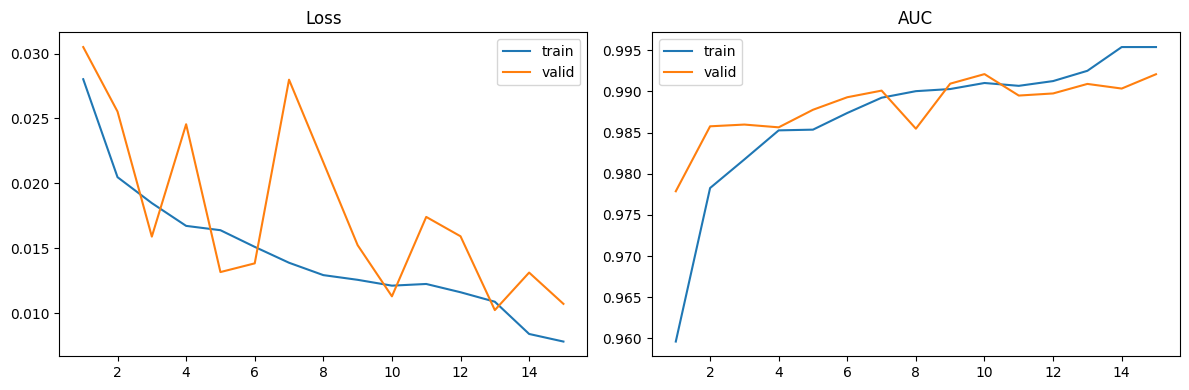

In [15]:
hist = pd.DataFrame(history)
display(hist)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], label="train")
axes[0].plot(hist["epoch"], hist["valid_loss"], label="valid")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist["epoch"], hist["train_auc"], label="train")
axes[1].plot(hist["epoch"], hist["valid_auc"], label="valid")
axes[1].set_title("AUC")
axes[1].legend()
plt.tight_layout()
plt.show()

In [16]:
@torch.no_grad()
def predict_loader(model, loader, use_tta=True):
    model.eval()
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        if use_tta and CFG.TTA_D4:
            preds = []
            for xt in d4_transforms(x):
                logits = model(xt)
                preds.append(torch.sigmoid(logits))
            probs = torch.stack(preds, dim=0).mean(dim=0)
        else:
            logits = model(x)
            probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y.numpy())

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_probs

val_targets, val_probs = predict_loader(model, valid_loader, use_tta=CFG.USE_TTA)
val_auc = roc_auc_score(val_targets, val_probs)
print("Validation AUC with TTA:", val_auc)

Validation AUC with TTA: 0.9925206181826977


Test AUC: 0.9820192554810905


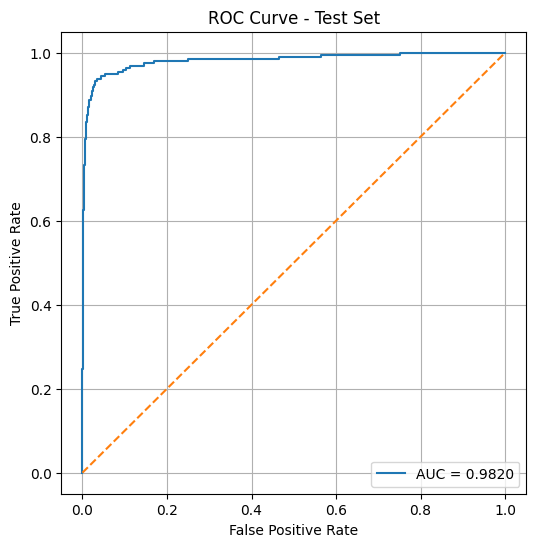

In [17]:
test_targets, test_probs = predict_loader(model, test_loader, use_tta=CFG.USE_TTA)
test_auc = roc_auc_score(test_targets, test_probs)
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

print("Test AUC:", test_auc)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# optional operating point inspection
for thr in [0.3, 0.5, 0.7]:
    preds = (test_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_targets, preds).ravel()
    tpr_ = tp / (tp + fn + 1e-9)
    fpr_ = fp / (fp + tn + 1e-9)
    print(f"thr={thr:.2f} | TP={tp} FP={fp} TN={tn} FN={fn} | TPR={tpr_:.4f} FPR={fpr_:.4f}")

thr=0.30 | TP=189 FP=2711 TN=16744 FN=6 | TPR=0.9692 FPR=0.1393
thr=0.50 | TP=185 FP=1183 TN=18272 FN=10 | TPR=0.9487 FPR=0.0608
thr=0.70 | TP=173 FP=370 TN=19085 FN=22 | TPR=0.8872 FPR=0.0190


## Recommended upgrades after the first clean run

1. **Switch backbone to `densenet161`**
   - If DenseNet-121 is stable and you still want a bit more capacity.

2. **3-seed ensemble**
   - Train with seeds `42, 1337, 2029`
   - Average logits/probabilities on validation and test
   - Usually a strong boost for ROC/AUC and especially low-FPR stability

3. **Hard-negative mining**
   - After epoch 5+, cache false positives from validation-like non-lenses
   - Oversample those in later epochs
   - This is especially useful because the scientific pain point is often contamination

4. **Ablation study**
   - DenseNet only
   - DenseNet + polar
   - DenseNet + polar + radial
   - This will show whether the physics-informed branch is helping

5. **Grad-CAM sanity checks**
   - Confirm the network is looking at arcs/rings and not just the central galaxy core

## Why this notebook is scientifically sensible

Strong lenses produce **tangential arcs and partial/complete Einstein rings** around a foreground lens.
That means the discriminative signal is not only “is there a bright feature?” but also **where that feature sits relative to the center and whether it is annular / tangential**.

A pure CNN can learn this, but a **polar branch makes the geometry easier to learn explicitly**:
- ring → horizontal stripe in polar space
- arc → localized band over a limited angle range
- non-lens bulge/spiral structure → usually less coherent in radius-angle space

That is the reason for the DensePolarNet design.